                          name releaseDate publisherClass  price    revenue  \
0                     WWE 2K24  2024-07-03            AAA  99.99  8055097.0   
9   Empires of the Undergrowth  2024-07-06             AA  29.99  6950952.0   
11                 ANIMAL WELL  2024-09-05          Indie  24.99  6420393.0   
12    Age of Mythology: Retold  2024-04-09            AAA  29.99  6381185.0   
16             Winter Memories  2024-05-01          Indie  19.99  5478333.0   

    gameAgeDays  
0            68  
9            65  
11            4  
12          153  
16          131  
  publisherClass  total_games  avg_price  median_revenue     avg_copies  \
0             AA           47  28.862340        670774.0  257929.446809   
1            AAA           26  21.339615        928862.0  537156.576923   
2       Hobbyist            1  24.990000         47871.0    3129.000000   
3          Indie          438  14.776689        101187.5   75410.461187   

   avg_review  
0   70.638298  
1   75.00

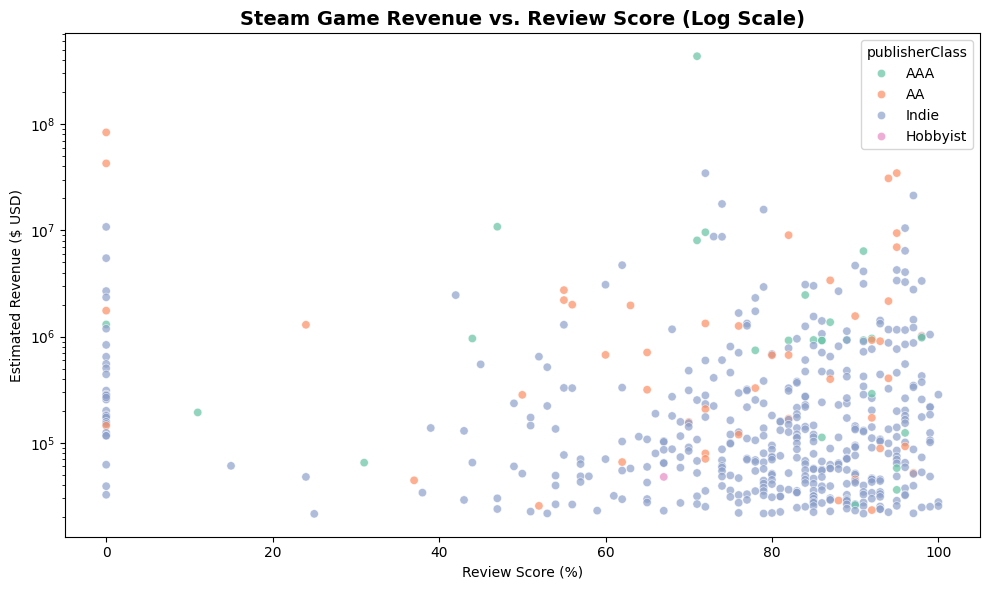

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/migueribau/data-games/Steam_2024_bestRevenue_1500.csv')

# 2. Convert date strings to datetime objects
df['releaseDate'] = pd.to_datetime(df['releaseDate'], errors='coerce')

# 3. Clean and convert numeric fields (strip $ or commas if stored as text)
numeric_cols = ['copiesSold', 'price', 'revenue', 'avgPlaytime', 'reviewScore']
for col in numeric_cols:
    if col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.replace('$', '').str.replace(',', '')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Filter out records missing key analysis fields
df = df.dropna(subset=['releaseDate', 'price'])

# 5. Feature Engineering: Calculate game age as of dataset snapshot (Sep 9, 2024)
snapshot_date = pd.to_datetime('2024-09-09')
df['gameAgeDays'] = (snapshot_date - df['releaseDate']).dt.days
df['revenuePerCopy'] = np.where(df['copiesSold'] > 0, df['revenue'] / df['copiesSold'], 0)

# 6. Display clean sample

print(df[['name', 'releaseDate', 'publisherClass', 'price', 'revenue', 'gameAgeDays']].head())
# Save cleaned DataFrame to a CSV file in your working directory
df.to_csv('/kaggle/working/cleaned_top_1500_steam_games.csv', index=False)


#Step 1: Perform Exploratory Data Analysis

# 1. Compare Publisher Classes (Indie vs. AA vs. AAA)
publisher_summary = df.groupby('publisherClass').agg(
    total_games=('name', 'count'),
    avg_price=('price', 'mean'),
    median_revenue=('revenue', 'median'),
    avg_copies=('copiesSold', 'mean'),
    avg_review=('reviewScore', 'mean')
).reset_index()

print(publisher_summary)

# 2. Revenue Efficiency: Price vs. Revenue
df['priceTier'] = pd.cut(
    df['price'], 
    bins=[-1, 0, 10, 30, 60, 1000], 
    labels=['Free', 'Budget (<$10)', 'Mid-Tier ($10-$30)', 'Premium ($30-$60)', 'AAA ($60+)']
)

tier_performance = df.groupby('priceTier', observed=False)['revenue'].agg(['count', 'median', 'mean'])
print(tier_performance)

# Create a plot showing Revenue vs. Review Score by Publisher Class
# Ensure the output directory exists
os.makedirs('visuals', exist_ok=True)

# Create your plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='reviewScore', 
    y='revenue', 
    hue='publisherClass', 
    alpha=0.7, 
    palette='Set2'
)
plt.yscale('log')
plt.title('Steam Game Revenue vs. Review Score (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Review Score (%)')
plt.ylabel('Estimated Revenue ($ USD)')
plt.tight_layout()

# Save image (now safely creates inside 'visuals/')
plt.savefig('visuals/revenue_vs_review_score.png', dpi=300)
plt.show()